# Buổi 2: Perceptron – Hamming – Hopfield

Ba mô hình nền tảng theo lộ trình tăng dần:
1. **Perceptron** — ra quyết định nhị phân (đi concert?).
2. **Hamming** — nhận dạng mẫu gần nhất (chữ C/I/T).
3. **Hopfield** — phục hồi mẫu bị nhiễu (sơ đồ ghế lỗi).

Cách học: chạy lần lượt, mỗi phần đều có phép tính tay rồi kiểm tra bằng code.

---
## Phần 1: Perceptron — Quyết định đi concert

**Bài toán:** Có đi concert không? Điều kiện:
- `x₁ = 1` nếu nghệ sĩ xịn, `0` nếu không.
- `x₂ = 1` nếu có bạn rủ, `0` nếu không.
- Luật AND: chỉ đi khi **cả hai** điều kiện đúng.

**Công thức:**
```
net = w₁·x₁ + w₂·x₂ + b
y = 1 nếu net ≥ 0, y = 0 nếu net < 0
```

**Thiết kế tay:** `w₁=1, w₂=1, b=−1.5`

### 1.1 Kiểm tra bảng chân trị AND

In [5]:
import numpy as np

# Trọng số thiết kế tay cho AND
w1, w2, b = 0,1.0, -0.5

# Hàm bước (step function)
def step(net):
    return 1 if net >= 0 else 0

# Bảng chân trị AND
print("x1  x2  | net    | y  | Diễn giải")
print("-" * 50)
cases = [
    (0, 0, "Nghệ sĩ thường, không bạn → không đi"),
    (0, 1, "Có bạn nhưng nghệ sĩ không xịn → không đi"),
    (1, 0, "Nghệ sĩ xịn nhưng không ai rủ → không đi"),
    (1, 1, "Nghệ sĩ xịn VÀ có bạn rủ → ĐI concert!"),
]

for x1, x2, desc in cases:
    net = w1 * x1 + w2 * x2 + b
    y = step(net)
    print(f" {x1}   {x2}  | {net:+.1f}  |  {y}  | {desc}")

x1  x2  | net    | y  | Diễn giải
--------------------------------------------------
 0   0  | -0.5  |  0  | Nghệ sĩ thường, không bạn → không đi
 0   1  | +0.5  |  1  | Có bạn nhưng nghệ sĩ không xịn → không đi
 1   0  | -0.5  |  0  | Nghệ sĩ xịn nhưng không ai rủ → không đi
 1   1  | +0.5  |  1  | Nghệ sĩ xịn VÀ có bạn rủ → ĐI concert!


### 1.2 Luật học Perceptron

Khi thiết kế tay không đủ, mạng tự sửa trọng số sau mỗi dự đoán sai:

```
wᵢ ← wᵢ + η·(t − y)·xᵢ
b  ← b  + η·(t − y)
```

Dưới đây mạng **học từ đầu** (w=0, b=0) để tìm ra trọng số cho AND:

In [1]:
# Dữ liệu huấn luyện AND
training_data = [
    (0, 0, 0),
    (0, 1, 0),
    (1, 0, 0),
    (1, 1, 1),
]

# Khởi tạo từ 0
w1, w2, b = 0.0, 0.0, 0.0
learning_rate = 0.1

print("Epoch | w1   w2    b     | Lỗi")
print("-" * 42)

for epoch in range(10):
    errors = 0
    for x1, x2, target in training_data:
        net = w1 * x1 + w2 * x2 + b
        y = 1 if net >= 0 else 0
        error = target - y
        # Cập nhật
        w1 += learning_rate * error * x1
        w2 += learning_rate * error * x2
        b  += learning_rate * error
        errors += abs(error)
    print(f"  {epoch+1:2d}  | {w1:.2f}  {w2:.2f}  {b:.2f}  |  {errors}")
    if errors == 0:
        print(f"\n✓ Hội tụ sau {epoch+1} epoch!")
        break

print(f"\nTrọng số học được: w1={w1:.2f}, w2={w2:.2f}, b={b:.2f}")

Epoch | w1   w2    b     | Lỗi
------------------------------------------
   1  | 0.10  0.10  0.00  |  2
   2  | 0.20  0.10  -0.10  |  3
   3  | 0.20  0.10  -0.20  |  3
   4  | 0.20  0.10  -0.20  |  0

✓ Hội tụ sau 4 epoch!

Trọng số học được: w1=0.20, w2=0.10, b=-0.20


### 1.3 Thử đổi sang OR

**Câu hỏi:** Giữ `w₁=w₂=1`, đổi bias thành bao nhiêu để thành OR?

**Đáp án:** `b = −0.5`

In [ ]:
# Perceptron OR: w1=1, w2=1, b=-0.5
w1, w2, b = 1.0, 1.0, -0.5

print("Perceptron OR")
print("x1  x2  | net    | y")
print("-" * 28)
for x1_val, x2_val in [(0,0), (0,1), (1,0), (1,1)]:
    net = w1 * x1_val + w2 * x2_val + b
    y = step(net)
    print(f" {x1_val}   {x2_val}  | {net:+.1f}  |  {y}")

### 1.4 Minh họa ranh giới quyết định

In [ ]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# --- AND ---
ax = axes[0]
ax.set_title("AND: x₁ + x₂ = 1.5", fontsize=12)
# Vùng quyết định
xx = np.linspace(-0.3, 1.5, 200)
ax.fill_between(xx, 1.5 - xx, 1.5, alpha=0.15, color='green', label='y=1 (đi)')
# Ranh giới
ax.plot(xx, 1.5 - xx, 'b-', linewidth=2, label='x₁+x₂=1.5')
# Điểm
points = [(0,0,0), (0,1,0), (1,0,0), (1,1,1)]
for x1_v, x2_v, t in points:
    color = 'green' if t == 1 else 'red'
    ax.scatter(x1_v, x2_v, c=color, s=120, zorder=5, edgecolors='black')
    ax.annotate(f'({x1_v},{x2_v})', (x1_v + 0.05, x2_v + 0.05))
ax.set_xlabel('x₁ (nghệ sĩ xịn?)')
ax.set_ylabel('x₂ (có bạn rủ?)')
ax.set_xlim(-0.3, 1.5)
ax.set_ylim(-0.3, 1.5)
ax.legend()
ax.grid(True, alpha=0.3)

# --- OR ---
ax = axes[1]
ax.set_title("OR: x₁ + x₂ = 0.5", fontsize=12)
ax.fill_between(xx, 0.5 - xx, 1.5, alpha=0.15, color='green', label='y=1 (đi)')
ax.plot(xx, 0.5 - xx, 'b-', linewidth=2, label='x₁+x₂=0.5')
points_or = [(0,0,0), (0,1,1), (1,0,1), (1,1,1)]
for x1_v, x2_v, t in points_or:
    color = 'green' if t == 1 else 'red'
    ax.scatter(x1_v, x2_v, c=color, s=120, zorder=5, edgecolors='black')
    ax.annotate(f'({x1_v},{x2_v})', (x1_v + 0.05, x2_v + 0.05))
ax.set_xlabel('x₁ (nghệ sĩ xịn?)')
ax.set_ylabel('x₂ (có bạn rủ?)')
ax.set_xlim(-0.3, 1.5)
ax.set_ylim(-0.3, 1.5)
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

---
## Phần 2: Mạng Hamming — Nhận dạng chữ C / I / T

**Bài toán:** Cho một lưới 3×3 (9 ô), mỗi ô mã hóa bipolar `+1` (đen) hoặc `−1` (trắng). So input với ba mẫu chuẩn C, I, T rồi chọn mẫu có điểm cao nhất.

**Công thức:** `yₖ = pₖᵀ · x` (tích vô hướng = số ô trùng − số ô khác)

**Lưu ý:** Dùng mã hóa bipolar {−1, +1}, KHÔNG dùng nhị phân {0, 1}.

### 2.1 Mẫu chuẩn C, I, T trên lưới 3×3

Quét hàng trái → phải, trên → dưới:

```
C:  ■ ■ ■    I:  □ ■ □    T:  ■ ■ ■
    ■ □ □        □ ■ □        □ ■ □
    ■ ■ ■        □ ■ □        □ ■ □
```

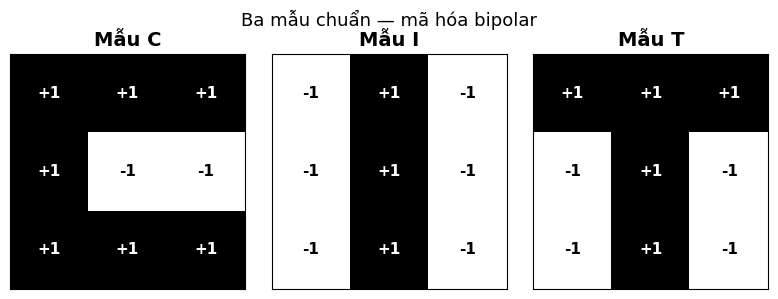

Vector mẫu:
  pC = [1, 1, 1, 1, -1, -1, 1, 1, 1]
  pI = [-1, 1, -1, -1, 1, -1, -1, 1, -1]
  pT = [1, 1, 1, -1, 1, -1, -1, 1, -1]


In [3]:
import numpy as np
import matplotlib.pyplot as plt

# Mẫu chuẩn (bipolar: +1 = đen, -1 = trắng)
patterns = {
    'C': np.array([ 1,  1,  1,  1, -1, -1,  1,  1,  1]),
    'I': np.array([-1,  1, -1, -1,  1, -1, -1,  1, -1]),
    'T': np.array([ 1,  1,  1, -1,  1, -1, -1,  1, -1]),
}

# Hiển thị lưới 3x3
fig, axes = plt.subplots(1, 3, figsize=(8, 3))
for ax, (name, p) in zip(axes, patterns.items()):
    grid = p.reshape(3, 3)
    ax.imshow(grid, cmap='gray_r', vmin=-1, vmax=1)
    ax.set_title(f'Mẫu {name}', fontsize=14, fontweight='bold')
    # Đánh số ô
    for i in range(3):
        for j in range(3):
            val = grid[i, j]
            color = 'white' if val == 1 else 'black'
            ax.text(j, i, f'{int(val):+d}', ha='center', va='center',
                    fontsize=11, color=color, fontweight='bold')
    ax.set_xticks([])
    ax.set_yticks([])
plt.suptitle('Ba mẫu chuẩn — mã hóa bipolar', fontsize=13)
plt.tight_layout()
plt.show()

print("Vector mẫu:")
for name, p in patterns.items():
    print(f"  p{name} = {p.tolist()}")

### 2.2 Tính điểm Hamming cho chữ C thiếu góc dưới phải

Input: chữ C nhưng ô thứ 9 bị đổi thành trắng (−1 thay vì +1):
```
■ ■ ■
■ □ □
■ ■ □  ← ô 9 bị sai
```

In [4]:
# Input: chữ C thiếu góc dưới phải
x = np.array([1, 1, 1, 1, -1, -1, 1, 1, -1])

P = np.array([patterns['C'], patterns['I'], patterns['T']])
names = ['C', 'I', 'T']

# Tính điểm = tích vô hướng
scores = P @ x

print("Tính từng cặp vị trí:")
print(f"{'Vị trí':>8}", end='')
for i in range(1, 10):
    print(f"{i:>4}", end='')
print(f"{'Tổng':>6}")
print("-" * 52)

for name, p in zip(names, P):
    products = p * x
    print(f"p{name}·x  ", end='')
    for prod in products:
        print(f"{int(prod):>4}", end='')
    print(f"{int(products.sum()):>6}")

print(f"\nĐiểm: C={scores[0]}, I={scores[1]}, T={scores[2]}")
winner = names[np.argmax(scores)]
print(f"→ Mẫu thắng: {winner} (điểm cao nhất = {scores.max()})")

Tính từng cặp vị trí:
  Vị trí   1   2   3   4   5   6   7   8   9  Tổng
----------------------------------------------------
pC·x     1   1   1   1   1   1   1   1  -1     7
pI·x    -1   1  -1  -1  -1   1  -1   1   1    -1
pT·x     1   1   1  -1  -1   1  -1   1   1     3

Điểm: C=7, I=-1, T=3
→ Mẫu thắng: C (điểm cao nhất = 7)


### 2.3 Demo tương tác: thử với input bất kỳ

Input: chữ T thiếu ô giữa trên
x = [1, -1, 1, -1, 1, -1, -1, 1, -1]

  Mẫu |  Điểm | Ô trùng | Ô khác
--------------------------------------
  C   |   -1  |   4/9   |   5/9  
  I   |    3  |   6/9   |   3/9  
  T   |    7  |   8/9   |   1/9   ← THẮNG


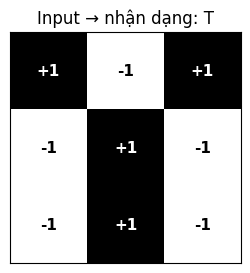

In [5]:
def hamming_classify(x_input, patterns_dict):
    """Nhận dạng mẫu gần nhất bằng mạng Hamming."""
    x = np.array(x_input)
    results = {}
    for name, p in patterns_dict.items():
        score = p @ x
        n_match = int((9 + score) / 2)  # số ô trùng
        n_diff = 9 - n_match              # số ô khác (khoảng cách Hamming)
        results[name] = {'score': int(score), 'match': n_match, 'diff': n_diff}
    
    best = max(results, key=lambda k: results[k]['score'])
    return results, best


# Thử nghiệm: Chữ T thiếu ô giữa trên (ô 2)
# T chuẩn: (1,1,1, -1,1,-1, -1,1,-1)
# T thiếu ô 2: (1,-1,1, -1,1,-1, -1,1,-1)
x_test = [1, -1, 1, -1, 1, -1, -1, 1, -1]

results, best = hamming_classify(x_test, patterns)

print("Input: chữ T thiếu ô giữa trên")
print(f"x = {x_test}\n")
print(f"{'Mẫu':>5} | {'Điểm':>5} | {'Ô trùng':>7} | {'Ô khác':>6}")
print("-" * 38)
for name, r in results.items():
    marker = " ← THẮNG" if name == best else ""
    print(f"  {name}   |  {r['score']:>3}  |   {r['match']}/9   |   {r['diff']}/9  {marker}")

# Hiển thị lưới input
fig, ax = plt.subplots(1, 1, figsize=(3, 3))
grid = np.array(x_test).reshape(3, 3)
ax.imshow(grid, cmap='gray_r', vmin=-1, vmax=1)
ax.set_title(f'Input → nhận dạng: {best}', fontsize=12)
for i in range(3):
    for j in range(3):
        val = grid[i, j]
        color = 'white' if val == 1 else 'black'
        ax.text(j, i, f'{int(val):+d}', ha='center', va='center',
                fontsize=11, color=color, fontweight='bold')
ax.set_xticks([])
ax.set_yticks([])
plt.show()

---
## Phần 3: Mạng Hopfield — Sửa sơ đồ ghế bằng nhớ liên tưởng

**Bài toán:** Có hai bố trí ghế cho phòng học:
- Mẫu A (thi cử): ghế cách nhau → `p¹ = (1, −1, 1)`
- Mẫu B (thảo luận): ghế gom nhóm → `p² = (1, 1, −1)`

Ba nơ-ron đại diện: x₁ (góc trái), x₂ (ghế giữa), x₃ (góc phải).

**Mạng Hopfield:**
- Dựng ma trận W bằng luật Hebb.
- Từ input lỗi, cập nhật từng nơ-ron cho đến khi ổn định.
- Trạng thái ổn định = mẫu đã nhớ.

### 3.1 Dựng ma trận W bằng luật Hebb

Công thức:
```
wᵢⱼ = ½(pᵢ¹·pⱼ¹ + pᵢ²·pⱼ²),  wᵢᵢ = 0
```

In [1]:
import numpy as np

# Hai mẫu chuẩn (rút gọn 3 nơ-ron)
p1 = np.array([ 1, -1,  1])  # Mẫu A: thi cử — ghế cách nhau
p2 = np.array([ 1,  1, -1])  # Mẫu B: thảo luận — ghế gom nhóm

print("Hai mẫu lưu:")
print(f"  p¹ (thi cử)    = {p1.tolist()}")
print(f"  p² (thảo luận) = {p2.tolist()}")

# Tính ma trận W bằng luật Hebb
# W = (1/P) * Σ pᵏ·pᵏᵀ, đường chéo = 0
P_count = 2  # số mẫu
W = (1 / P_count) * (np.outer(p1, p1) + np.outer(p2, p2))
np.fill_diagonal(W, 0)  # Không tự nối

print("\nTính từng cặp liên kết:")
print(f"  w₁₂ = ½(1×(−1) + 1×1) = ½(−1+1) = 0")
print(f"  w₁₃ = ½(1×1 + 1×(−1)) = ½(1−1)  = 0")
print(f"  w₂₃ = ½((−1)×1 + 1×(−1)) = ½(−1−1) = −1")

print("\nMa trận W:")
print(W)
print("\n→ Chỉ có liên kết ức chế (−1) giữa x₂ và x₃.")
print("  Nghĩa là: x₂ và x₃ có xu hướng ngược dấu nhau.")

Hai mẫu lưu:
  p¹ (thi cử)    = [1, -1, 1]
  p² (thảo luận) = [1, 1, -1]

Tính từng cặp liên kết:
  w₁₂ = ½(1×(−1) + 1×1) = ½(−1+1) = 0
  w₁₃ = ½(1×1 + 1×(−1)) = ½(1−1)  = 0
  w₂₃ = ½((−1)×1 + 1×(−1)) = ½(−1−1) = −1

Ma trận W:
[[ 0.  0.  0.]
 [ 0.  0. -1.]
 [ 0. -1.  0.]]

→ Chỉ có liên kết ức chế (−1) giữa x₂ và x₃.
  Nghĩa là: x₂ và x₃ có xu hướng ngược dấu nhau.


### 3.2 Phục hồi mẫu: Input lỗi (1, 1, 1) → ?

Sơ đồ ghế đánh dấu cả 3 vị trí đều có ghế — không khớp mẫu nào.

Quy tắc cập nhật bất đồng bộ:
```
netᵢ = Σⱼ≠ᵢ wᵢⱼ·xⱼ
xᵢ ← sign(netᵢ)   (nếu net=0 thì giữ nguyên)
```

In [6]:
def sign(val, current):
    """Hàm sign: +1 nếu > 0, -1 nếu < 0, giữ nguyên nếu = 0."""
    if val > 0:
        return 1
    elif val < 0:
        return -1
    else:
        return current


def hopfield_update(W, x, order=None, max_steps=10):
    """Cập nhật bất đồng bộ mạng Hopfield."""
    x = x.copy().astype(float)
    n = len(x)
    if order is None:
        order = list(range(n))
    
    log = [f"Trạng thái ban đầu: x = {x.astype(int).tolist()}"]
    
    for step in range(max_steps):
        changed = False
        for i in order:
            net_i = W[i] @ x
            new_val = sign(net_i, x[i])
            old_val = x[i]
            x[i] = new_val
            
            status = "→ đổi" if new_val != old_val else "→ giữ"
            log.append(
                f"  Bước: cập nhật x{i+1} | "
                f"net{i+1} = W[{i+1}]·x = {W[i]}·{x.astype(int).tolist()} "
                f"= {int(net_i)} | x{i+1}: {int(old_val)} {status} {int(new_val)}"
            )
            if new_val != old_val:
                changed = True
        
        log.append(f"  → Trạng thái hiện tại: x = {x.astype(int).tolist()}")
        
        if not changed:
            log.append(f"\n✓ Ổn định! Không nơ-ron nào thay đổi.")
            break
    
    return x.astype(int), log


# Input lỗi: cả ba vị trí đều có ghế
x_noisy = np.array([1, -1, 1])

print("="*60)
print("PHỤC HỒI MẪU HOPFIELD")
print("="*60)
print(f"Input lỗi: x = {x_noisy.tolist()} (cả 3 vị trí đều có ghế?)\n")

# Cập nhật theo thứ tự x₂ → x₃ (x₁ không bị ảnh hưởng vì hàng 0 toàn 0)
x_result, log = hopfield_update(W, x_noisy, order=[0, 1, 2])

for line in log:
    print(line)

# Kiểm tra kết quả
if np.array_equal(x_result, p1):
    print(f"\n→ Kết quả: x* = {x_result.tolist()} = p¹ (Mẫu A · thi cử)")
elif np.array_equal(x_result, p2):
    print(f"\n→ Kết quả: x* = {x_result.tolist()} = p² (Mẫu B · thảo luận)")
else:
    print(f"\n→ Kết quả: x* = {x_result.tolist()} (không khớp mẫu nào — trạng thái giả)")

PHỤC HỒI MẪU HOPFIELD
Input lỗi: x = [1, -1, 1] (cả 3 vị trí đều có ghế?)

Trạng thái ban đầu: x = [1, -1, 1]
  Bước: cập nhật x1 | net1 = W[1]·x = [0. 0. 0.]·[1, -1, 1] = 0 | x1: 1 → giữ 1
  Bước: cập nhật x2 | net2 = W[2]·x = [ 0.  0. -1.]·[1, -1, 1] = -1 | x2: -1 → giữ -1
  Bước: cập nhật x3 | net3 = W[3]·x = [ 0. -1.  0.]·[1, -1, 1] = 1 | x3: 1 → giữ 1
  → Trạng thái hiện tại: x = [1, -1, 1]

✓ Ổn định! Không nơ-ron nào thay đổi.

→ Kết quả: x* = [1, -1, 1] = p¹ (Mẫu A · thi cử)


### 3.3 Kiểm tra: mẫu chuẩn đã lưu có ổn định không?

In [ ]:
print("Kiểm tra mẫu A (thi cử): p¹ = (1, -1, 1)")
print("-" * 50)
x_a, log_a = hopfield_update(W, p1.copy(), order=[0, 1, 2])
for line in log_a:
    print(line)

print("\n")
print("Kiểm tra mẫu B (thảo luận): p² = (1, 1, -1)")
print("-" * 50)
x_b, log_b = hopfield_update(W, p2.copy(), order=[0, 1, 2])
for line in log_b:
    print(line)

### 3.4 Thử thêm các input lỗi khác

In [ ]:
test_cases = [
    ([1, 1, 1],   "Cả 3 có ghế"),
    ([-1, -1, -1], "Cả 3 trống"),
    ([1, -1, -1],  "Chỉ góc trái"),
    ([-1, 1, -1],  "Chỉ ghế giữa"),
    ([-1, -1, 1],  "Chỉ góc phải"),
]

print(f"{'Input':>15} | {'Mô tả':>16} | {'Kết quả':>12} | Mẫu")
print("-" * 62)

for x_test, desc in test_cases:
    x_out, _ = hopfield_update(W, np.array(x_test), order=[0, 1, 2])
    
    if np.array_equal(x_out, p1):
        label = "A (thi cử)"
    elif np.array_equal(x_out, p2):
        label = "B (thảo luận)"
    else:
        label = "(khác)"
    
    print(f"{str(x_test):>15} | {desc:>16} | {str(x_out.tolist()):>12} | {label}")

---
## So sánh ba mô hình

| Tiêu chí | Perceptron | Hamming | Hopfield |
|----------|-----------|---------|----------|
| **Ví dụ** | Đi concert? | Chữ là C/I/T? | Sơ đồ ghế lỗi về mẫu nào? |
| **Kiến trúc** | 1 lớp, feedforward | So mẫu + MAXNET | 1 lớp, hồi tiếp |
| **Mã hóa** | Nhị phân {0, 1} | Bipolar {−1, +1} | Bipolar {−1, +1} |
| **Đầu ra** | 0 / 1 | Mẫu gần nhất | Trạng thái ổn định |
| **Giới hạn** | Chỉ tách tuyến tính | Mẫu cố định | Ít mẫu, có trạng thái giả |

**Một câu để nhớ:** Perceptron vạch ranh giới; Hamming chọn mẫu gần nhất; Hopfield biến đổi trạng thái cho tới khi chạm mẫu đã nhớ.

---
## Bài tập

**A.** Đổi Perceptron AND thành OR: giữ `w₁=w₂=1`, tìm bias mới.

**B.** Vẽ chữ T thiếu ô giữa trên, tính điểm Hamming với C/I/T.

**C.** Bắt đầu từ `(1, −1, 1)`, cập nhật 3 nơ-ron Hopfield và chứng minh mẫu A ổn định.

**D.** Nếu thêm mẫu C cho KTX, ma trận W có phải tính lại không? Vì sao?